# A2TTA hyper-parameter sensitivity — Ours on **both** backbones (OL-AN & STAEformer)

One-at-a-time (OAT) sweep of six knobs around the default config
`lr1e-3 / steps3 / pool512 / budget0.25 / warmup3 / local3`. Each panel varies a
single knob (others held at default); two lines = the two backbones; shaded band
= ±std across the three datasets; dotted vertical = the default value.

- **Source:** `eac/run_logs/hpAna_*/csv/HPA_<bb>_<DSID>__<knob>__<val>__s<seed>.csv`
  — the 324-job OAT batch (`submit_hpanalysis.sh`). Each CSV has one
  `horizon=="Avg"` row per year; the per-seed scalar is the mean over years
  (identical to how the main-table / sweep aggregate).
- **Normalisation:** each (dataset, backbone) Avg-MAE is divided by its own
  **anchor** run → %ΔMAE, then averaged over PEMS03/05/06 (seeds 51-53). The
  single anchor run is the default-value point of all six curves ⇒ that point is
  0 by construction.
- **Knobs:** `adapt_lr`, `adapt_steps`, `candidate_pool_size`, `budget_frac`,
  `warmup_epochs`, `local_steps`.
- **Reading it:** curves stay within a few % of 0 everywhere except low
  `adapt_lr` — Ours is robust to its hyper-parameters; only the TTA learning
  rate matters, with a flat optimum around 1e-3–3e-3. Both backbones agree.
- **Tuning:** the *STYLE / LAYOUT KNOBS* cell below sets every font size, panel
  geometry and the legend gap — edit and re-run. Defaults live at the top of
  `render_hyper_a2tta.py`.
- **Outputs:** `hyper_a2tta.{png,pdf}` (400 dpi PNG + true-vector PDF).


In [ ]:
%matplotlib inline
import os, sys, importlib
sys.path.insert(0, os.getcwd())          # notebook lives in figs_paper/
import render_hyper_a2tta as rh
importlib.reload(rh)
from IPython.display import Image, display
print("backbones:", [lab for _bb, lab, _s in rh.BACKBONES])
print("knobs    :", [k for k, *_ in rh.HP_SPEC])
print("csv glob :", rh.CSV_GLOB)


In [23]:
# ============================ STYLE / LAYOUT KNOBS ============================
# Edit any of these, then re-run the render cell below. (Full list + comments at
# the top of render_hyper_a2tta.py.)  *_FS = font points, *_IN = inches.
rh.PANEL_W_IN      = 2.55    # subplot width  (inches)
rh.PANEL_H_IN      = 2.15    # subplot height (inches)
rh.WSPACE          = 0.34    # horizontal gap between panels
rh.HSPACE          = 0.52    # vertical gap between panels
rh.LEGEND_STRIP_IN = 0.62    # top strip reserved for the legend row
                             #   -> SHRINK to pull the legend closer to the panels

rh.TITLE_FS        = 11.0    # panel title (knob name)
rh.LABEL_FS        = 13.0    # axis labels
rh.TICK_FS         = 13    # tick labels
rh.LEGEND_FS       =  13    # legend font
rh.ANNOT_FS  =  13    # max = 7.1
rh.LINE_LW         = 1.9     # curve line width
rh.MARKER_MS       = 7.0     # marker size
rh.BAND_ALPHA      = 0.16    # shaded std-band opacity
rh.ANNOTATE_WORST  = True    # print worst-case %Delta in each panel
rh.DPI_SAVE        = 400     # PNG dpi (PDF is always true-vector)


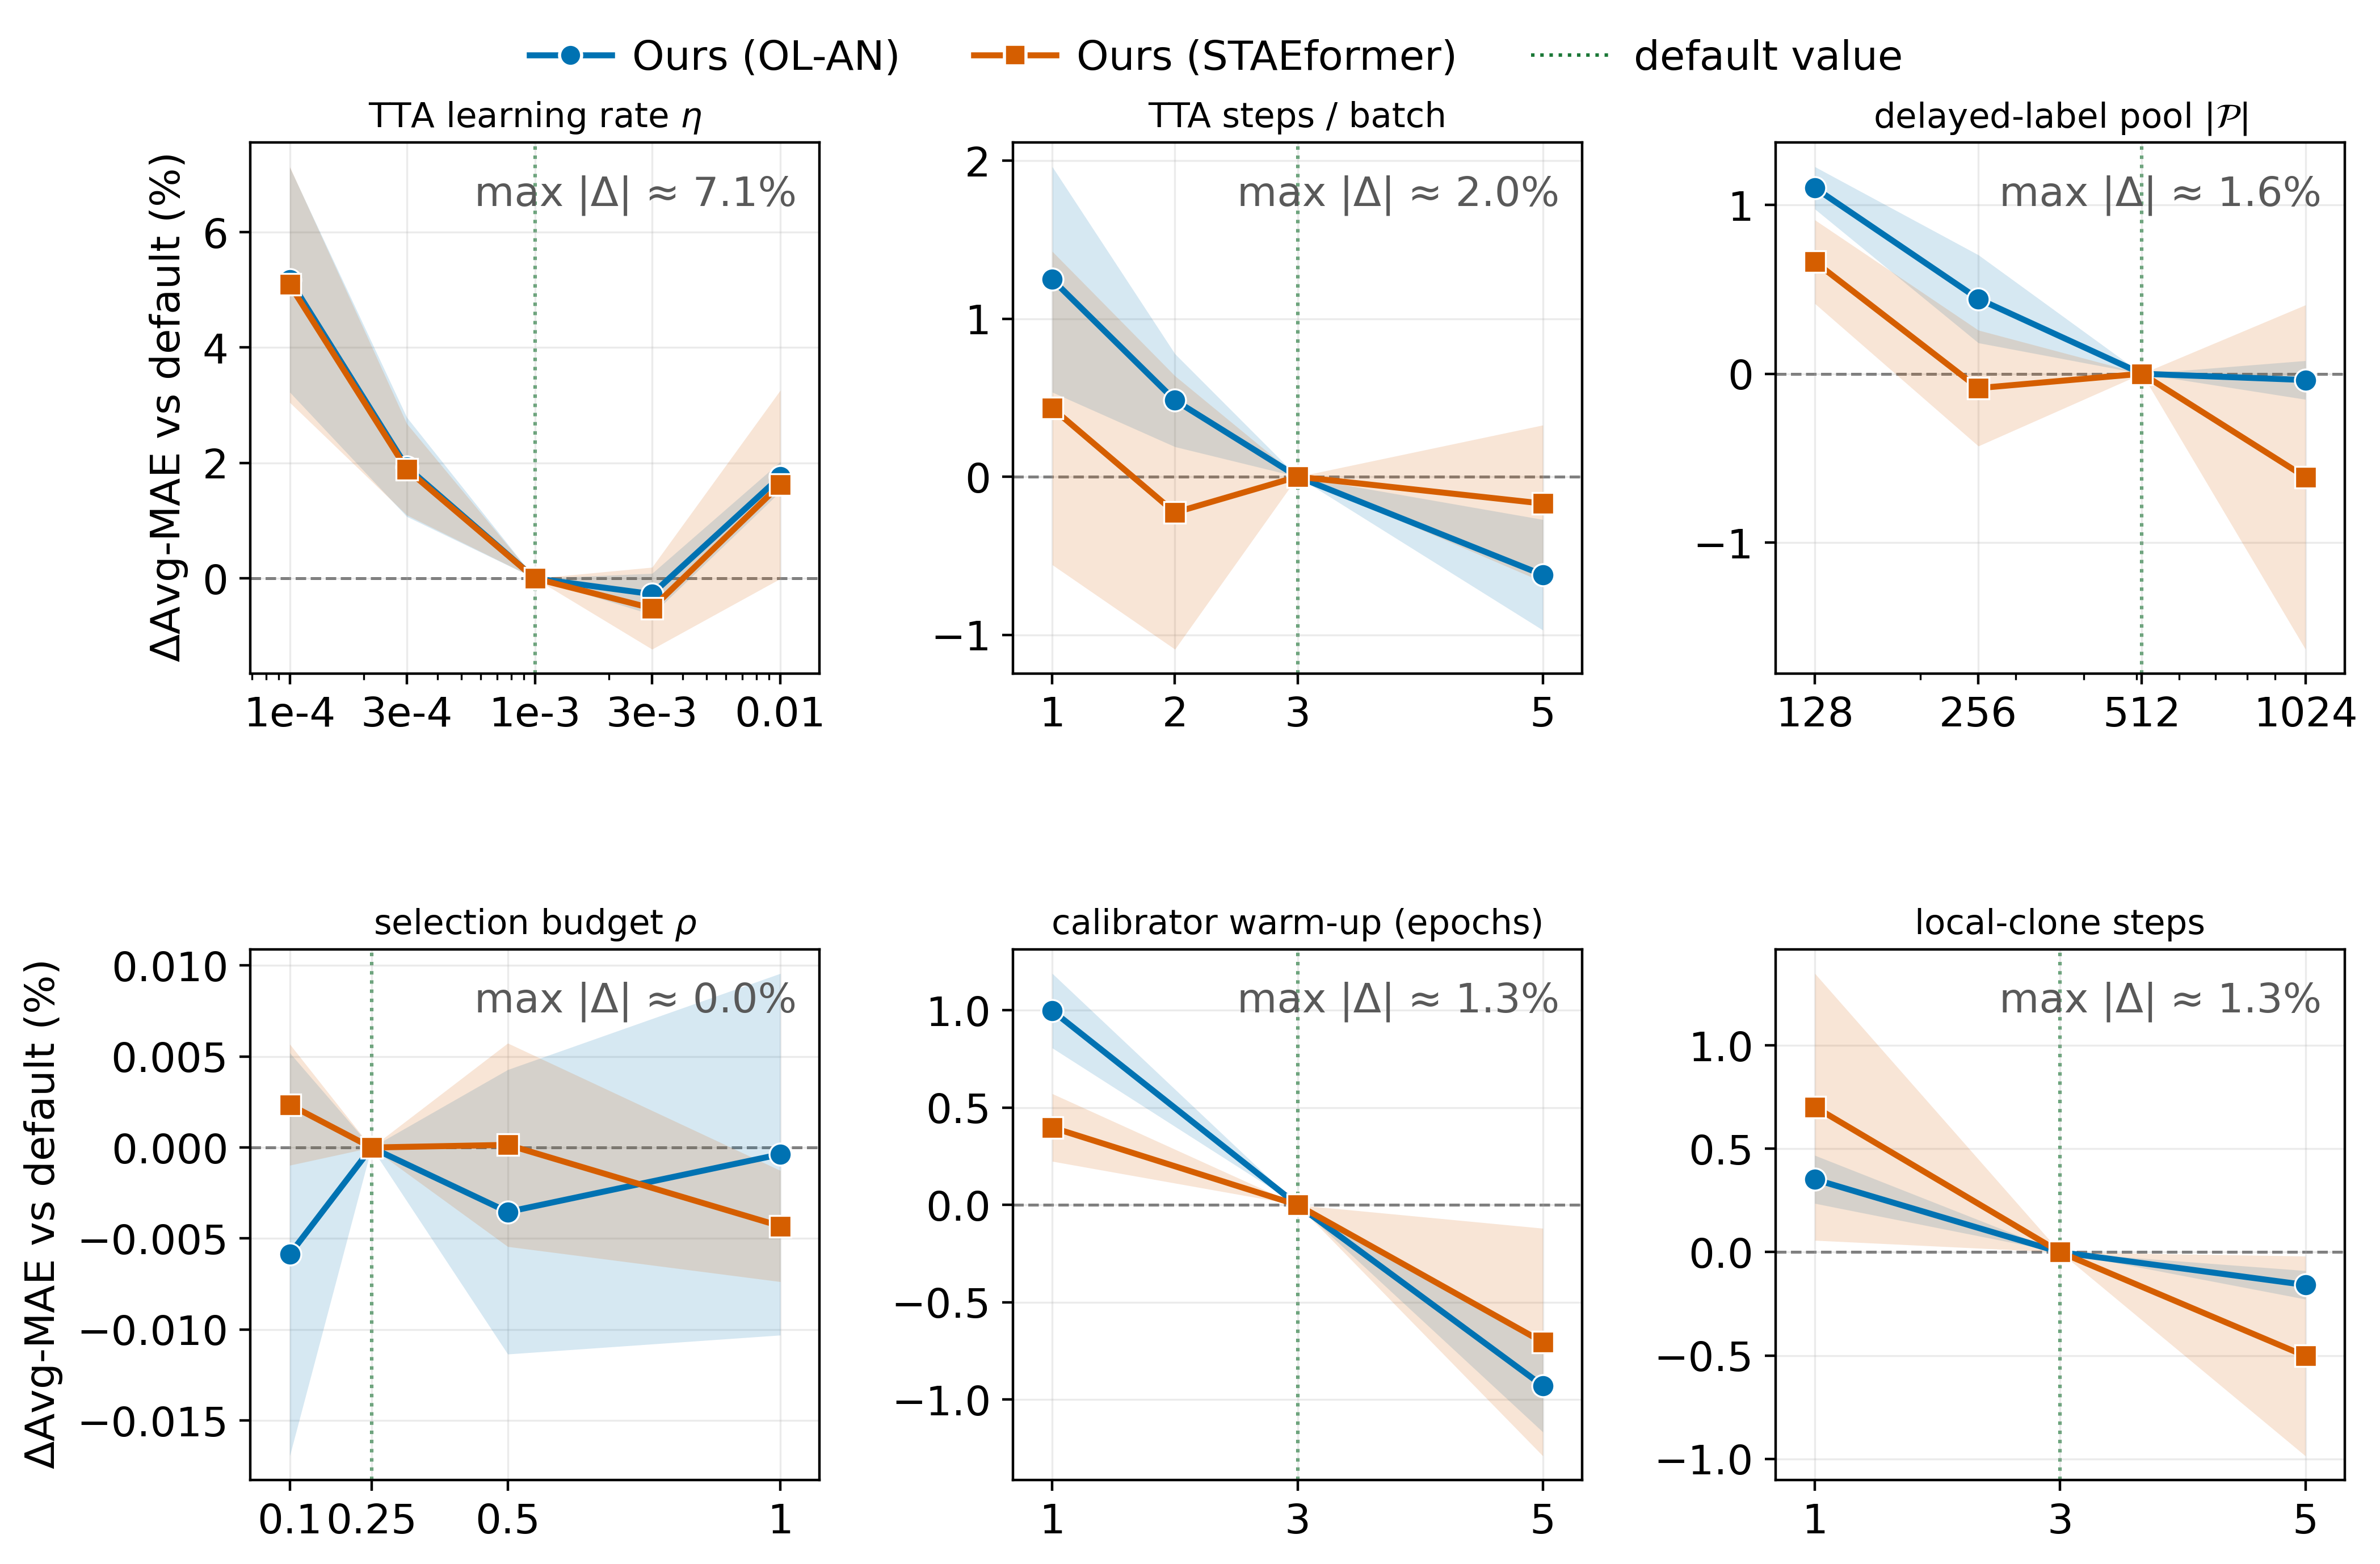

In [ ]:
# Renders with the knobs set in the cell ABOVE. Do NOT importlib.reload(rh)
# here — a reload resets every knob to the file defaults and would silently
# undo your edits. If you changed render_hyper_a2tta.py *itself*, re-run the
# imports cell, then the knobs cell, then this one.
png, pdf = rh.build("hyper_a2tta")   # writes hyper_a2tta.png + .pdf
display(Image(filename=png))


## What these panels show — 这组图说明了什么

**EN.** Each panel perturbs a single hyper-parameter around the default (green
dotted line) and reports the relative change in Avg-MAE; the two lines are the
two backbones and the band is $\pm$std over PEMS03/05/06 (seeds 51--53).

1. **Robust.** The worst single-knob degradation is only $\approx\!5\%$, and it
   occurs solely at an under-sized TTA learning rate ($10^{-4}$); every other
   knob keeps the error within $\pm1.3\%$.
2. **Only the TTA learning rate matters**, and even it has a *flat optimum*
   spanning $10^{-3}$--$3\times10^{-3}$ (a shallow U). Our default $10^{-3}$
   sits in that basin.
3. **The novel online components are not brittle.** The delayed-label pool,
   calibrator warm-up and local-clone steps are near-flat; the active-selection
   budget is essentially inert ($\pm0.01\%$). More adapt-steps / warm-up give
   small, quickly-saturating gains.
4. **Both backbones trace nearly identical curves** ⇒ the default configuration
   `lr1e-3/st3/pool512/budget0.25/wu3/local3` transfers across backbones without
   re-tuning.

**中文.** 每格围绕默认配置(绿点线)扰动单个超参,画 Avg-MAE 相对变化;两条线=两
backbone,阴影带=PEMS03/05/06(seed 51--53)的 $\pm$std。

1. **鲁棒**:单旋钮最大退化仅 $\approx\!5\%$,且只出现在 TTA 学习率过小($10^{-4}$)时;
   其余旋钮误差均在 $\pm1.3\%$ 内。
2. **唯一实质重要的是 TTA 学习率**,且其最优是 $10^{-3}$--$3\times10^{-3}$ 的*平坦谷底*
   (浅 U 形);默认 $10^{-3}$ 正落谷内。
3. **新颖在线组件不脆弱**:延迟标签池、校准器 warmup、局部 clone 步数几乎无影响;
   主动选择预算近乎惰性($\pm0.01\%$)。增加自适应步数/warmup 只带来快速饱和的小增益。
4. **两 backbone 曲线几乎重合** ⇒ 默认配置 `lr1e-3/st3/pool512/budget0.25/wu3/local3`
   可跨 backbone 直接迁移、无需重调。


In [ ]:
# ---- the exact %DeltaMAE numbers behind the curves (paper table / text) ----
raw = rh.load()
curve, anchor, dsids = rh.curves(raw)
print("datasets:", dsids, " (mean over these; seeds 51-53)\n")
for bb, lab, _s in rh.BACKBONES:
    print(f"== {lab} ==")
    for knob, lbl, vals, anc, _sc in rh.HP_SPEC:
        cells = []
        for v in vals:
            if (bb, knob, v) in curve:
                mu, sd, _ = curve[(bb, knob, v)]
                mark = "*" if abs(v-anc) < 1e-12 else " "
                cells.append(f"{v}{mark}={mu:+.2f}±{sd:.2f}")
        print(f"  {lbl:32s}: " + "  ".join(cells))
    print(f"  anchor Avg-MAE: " +
          ", ".join(f"{d}={anchor.get((bb,d),float('nan')):.2f}" for d in dsids))
    print()
